In [1]:
from pathlib import Path
from time import sleep

import matplotlib.pyplot as plt
import numpy as np

from pyaml.accelerator import Accelerator
from pyaml.common.constants import Action

## Facility configuration

Edit the `CONFIG_FILE` variable below to select the facility. The rest of the notebook runs unchanged.

| Facility | Config file | Control system | Virtual twin |
|----------|-------------|----------------|--------------|
| SOLEIL II | `config/soleil_ii/p.yaml` | TANGO (`tango-pyaml`) | Apptainer container |
| BESSY2 | `config/bessy2/bessy2.yaml` | EPICS (`pyaml-cs-oa`) | Apptainer container |
| ESRF EBS | `config/esrf/esrf.yaml` | TANGO (`tango-pyaml`) | Apptainer container |

See `README.md` for installation and virtual accelerator startup instructions.

In [2]:
# ── Facility configuration ──────────────────────────────────────────────────
# Uncomment the facility you want to use:

# CONFIG_FILE = "config/soleil_ii/p.yaml"
CONFIG_FILE = "config/bessy2/bessy2.yaml"
# CONFIG_FILE = "config/esrf/esrf.yaml"
# ────────────────────────────────────────────────────────────────────────────

CONFIG_DIR = Path(CONFIG_FILE).parent

sr = Accelerator.load(CONFIG_FILE)
sr  # string representation

PyAML OA control system binding (0.1.2) initialized with name 'live' and prefix='pons:'


14 Aug 2026, 14:23:11 | WARNING | Loading /home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/bessy2/orm.json failed /home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/bessy2/orm.json: file not found


Accelerator(facility='BESSY2', machine='sr', description=None, live=OphydAsyncControlSystem(name='live', prefix='pons:', catalog=<pyaml_cs_oa.dynamic_catalog.DynamicCatalog object at 0x77fdb791eea0>, debug_level=None), design=Simulator(name='design', lattice='/home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/bessy2/bessy2_standard_user.mat', mat_key=None, linker=None, description=None), yellow_pages=Controls:
    live
    .

Simulators:
    design
    .

Arrays:
    BPM                   (pyaml.arrays.bpm_array)                size=123
    HCorr                 (pyaml.arrays.magnet_array)             size=48
    VCorr                 (pyaml.arrays.magnet_array)             size=64
    QForTune              (pyaml.arrays.magnet_array)             size=64
    .

Tools:
    DEFAULT_ORBIT_RESPONSE_MATRIX (pyaml.tuning_tools.orbit_response_matrix)
    DEFAULT_DISPERSION (pyaml.tuning_tools.dispersion)
    DEFAULT_ORBIT_CORRECTION (pyaml.tuning_tools.orbit)
    DE

### Virtual accelerator setup

For **live** control mode you need a running control system or emulator. If you want to skip this, run the notebook in **design** mode only.

**SOLEIL II / ESRF (TANGO)**
```
apptainer pull virtual-accelerator.sif oras://gitlab-registry.synchrotron-soleil.fr/software-control-system/containers/apptainer/virtual-accelerator:latest
apptainer run virtual-accelerator.sif
```

**BESSY2 (EPICS)**
```
apptainer run oras://registry.hzdr.de/digital-twins-for-accelerators/containers/pyat-softioc-digital-twin:default-v0-5-1-bessy.2711893
```

> **Note for BESSY2 live mode:** the PV prefix in `config/bessy2/bessy2.yaml` must match your virtual accelerator instance. Edit the `prefix:` field under `controls:`.

### Control mode choice

- **`sr.design`** runs in simulation, no control system needed. ORM measurement is fast (set `wait_time = 0.0`).
- **`sr.live`** connects to the real machine or twin. Use `wait_time ≥ 1.5 s` for settling.

> **BESSY2 live note:** BPM readbacks may be in nm. `orbit_correction.correct(gain=1e-9)` compensates for the unit mismatch when using a design-mode ORM to correct on live.

In [3]:
SR = sr.design
# SR = sr.live

wait_time = 0.0 if SR == sr.design else 2.0
SR  # string representation

Simulator(name='design', lattice='/home/gubaidulin/codes/operation/pyAML/pyaml/examples/unified_examples/config/bessy2/bessy2_standard_user.mat', mat_key=None, linker=None, description=None)

#### Orbit diagnostics and correctors

In [4]:
bpms = SR.get_bpms("BPM")
hcorr = SR.get_magnets("HCorr")
vcorr = SR.get_magnets("VCorr")
print(f"BPMs: {len(bpms)}, H correctors: {len(hcorr)}, V correctors: {len(vcorr)}")

BPMs: 123, H correctors: 48, V correctors: 64


### Orbit response matrix

The ORM can be saved in multiple formats. Load it into `SR.orbit` before correcting.

In [5]:
SR.orm  # string representation

OrbitResponseMatrix(peer='Simulator:design', name='DEFAULT_ORBIT_RESPONSE_MATRIX', description=None, lattice_names=None, n_step=1, sleep_between_step=0, n_avg_meas=1, sleep_between_meas=0, bpm_array_name='BPM', hcorr_array_name='HCorr', vcorr_array_name='VCorr', corrector_delta=1e-06)

In [6]:
SR.orm.measure(sleep_between_step=wait_time)
SR.orm.save(CONFIG_DIR / "orm.json")
SR.orm.save(CONFIG_DIR / "orm.yaml", with_type="yaml")
SR.orm.save(CONFIG_DIR / "orm.npz", with_type="npz")

SR.orbit.load(CONFIG_DIR / "orm.json")
print("ORM measured, saved and loaded.")

14 Aug 2026, 14:23:14 | INFO | Measuring correctors from the default arrays: HCorr and VCorr.
14 Aug 2026, 14:23:14 | INFO | Measured response of HS4M2D1R.
14 Aug 2026, 14:23:14 | INFO | Measured response of HS1MT1R.
14 Aug 2026, 14:23:14 | INFO | Measured response of HS4M1T1R.
14 Aug 2026, 14:23:14 | INFO | Measured response of HS4M2T1R.
14 Aug 2026, 14:23:15 | INFO | Measured response of HS1MD2R.
14 Aug 2026, 14:23:15 | INFO | Measured response of HS4M1D2R.
14 Aug 2026, 14:23:15 | INFO | Measured response of HS4M2D2R.
14 Aug 2026, 14:23:15 | INFO | Measured response of HS1MT2R.
14 Aug 2026, 14:23:15 | INFO | Measured response of HS4M1T2R.
14 Aug 2026, 14:23:15 | INFO | Measured response of HS4M2T2R.
14 Aug 2026, 14:23:15 | INFO | Measured response of HS1MD3R.
14 Aug 2026, 14:23:16 | INFO | Measured response of HS4M1D3R.
14 Aug 2026, 14:23:16 | INFO | Measured response of HS4M2D3R.
14 Aug 2026, 14:23:16 | INFO | Measured response of HS1MT3R.
14 Aug 2026, 14:23:16 | INFO | Measured res

#### Visualise the orbit response matrix

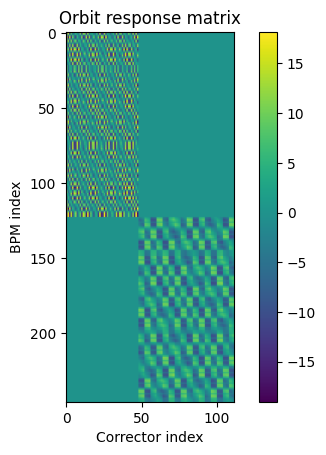

In [7]:
orm_data = SR.orm.get()
plt.imshow(np.array(orm_data["matrix"]))
plt.colorbar()
plt.title("Orbit response matrix")
plt.xlabel("Corrector index")
plt.ylabel("BPM index")
plt.show()

### Dispersion measurement (optional)

The dispersion can be measured and incorporated into the ORM to enable RF-based orbit correction. This is particularly useful for correcting closed-orbit distortions caused by energy errors.

In [8]:
# Uncomment to measure and visualise dispersion

# def disp_callback(action: int, cb_data) -> bool:
#     from pyaml.common.constants import Action
#     if action == Action.APPLY:
#         print("Changing RF frequency")
#     elif action == Action.MEASURE:
#         print("Reading orbit")
#     elif action == Action.RESTORE:
#         print("Restoring RF frequency")
#     return True

# SR.dispersion.measure(callback=disp_callback)
# disp_data = SR.dispersion.get()
# plt.plot(disp_data["frequency_response_x"], label="H dispersion")
# plt.plot(disp_data["frequency_response_y"], label="V dispersion")
# plt.xlabel("BPM index")
# plt.ylabel("Orbit / Δf [m/Hz]")
# plt.legend()
# plt.show()

### Introduce orbit distortion

Reset correctors to zero, then add small random kicks to simulate a disturbed orbit.

In [9]:
# Reset correctors to zero
hcorr.strengths.set(np.zeros(len(hcorr)))
vcorr.strengths.set(np.zeros(len(vcorr)))
ref_h, ref_v = SR.get_bpms("BPM").positions.get().T
reference = np.concatenate((ref_h, ref_v))

# Add random kicks to simulate a distorted orbit
np.random.seed(1)
std_kick = 1e-6  # rad
hcorr.strengths.set(hcorr.strengths.get() + std_kick * np.random.normal(size=len(hcorr)))
vcorr.strengths.set(vcorr.strengths.get() + std_kick * np.random.normal(size=len(vcorr)))

In [10]:
positions_bc = bpms.positions.get()
std_bc = np.std(positions_bc, axis=0)
print(f"R.m.s. orbit before correction — H: {1e6 * std_bc[0]:.1f} µm, V: {1e6 * std_bc[1]:.1f} µm")

R.m.s. orbit before correction — H: 81.0 µm, V: 32.8 µm


#### Orbit before correction

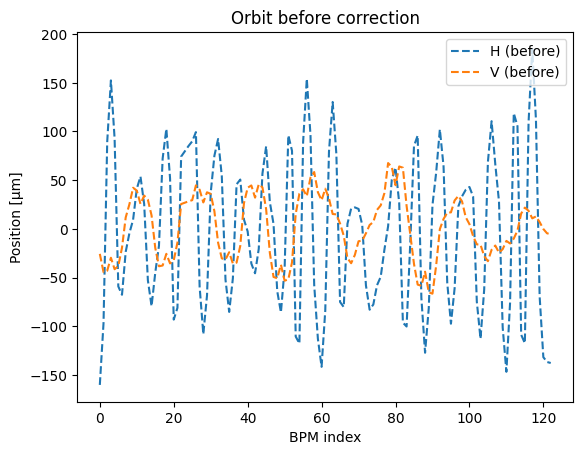

In [11]:
plt.figure()
plt.plot(positions_bc[:, 0] * 1e6, label="H (before)", color="C0", ls="--")
plt.plot(positions_bc[:, 1] * 1e6, label="V (before)", color="C1", ls="--")
plt.xlabel("BPM index")
plt.ylabel("Position [µm]")
plt.legend()
plt.title("Orbit before correction")
plt.show()

### Correct the orbit

Standard correction: `SR.orbit.correct(reference=reference)`.

Optional variants (uncomment to use):
- **Virtual corrector weight**: down-weights correctors that are already at large strengths.
- **RF correction**: also adjusts the RF frequency to minimise dispersion-driven orbit.
- **Live unit mismatch**: if BESSY2 BPMs read in nm, pass `gain=1e-9`.

In [12]:
# Standard correction
SR.orbit.correct(reference=reference)

# With virtual corrector weight (ESRF style):
# SR.orbit.set_virtual_weight(1000)
# SR.orbit.correct(reference=reference)

# With RF orbit correction (ESRF style, requires dispersion in ORM):
# SR.orbit.correct(reference=reference, rf=True)

# BESSY2 live mode — BPMs in nm, use gain to compensate unit mismatch:
# SR.orbit.correct(reference=reference, gain=1e-9)

sleep(wait_time)

14 Aug 2026, 14:23:32 | INFO | (Re-)Building pseudoinverse RM with method='svd_values', parameter=16, plane='H', virtual=True, rf=False.
14 Aug 2026, 14:23:32 | INFO | (Re-)Building pseudoinverse RM with method='svd_values', parameter=16, plane='V', virtual=False, rf=False.


R.m.s. orbit after correction  — H: 7.3 µm, V: 2.2 µm


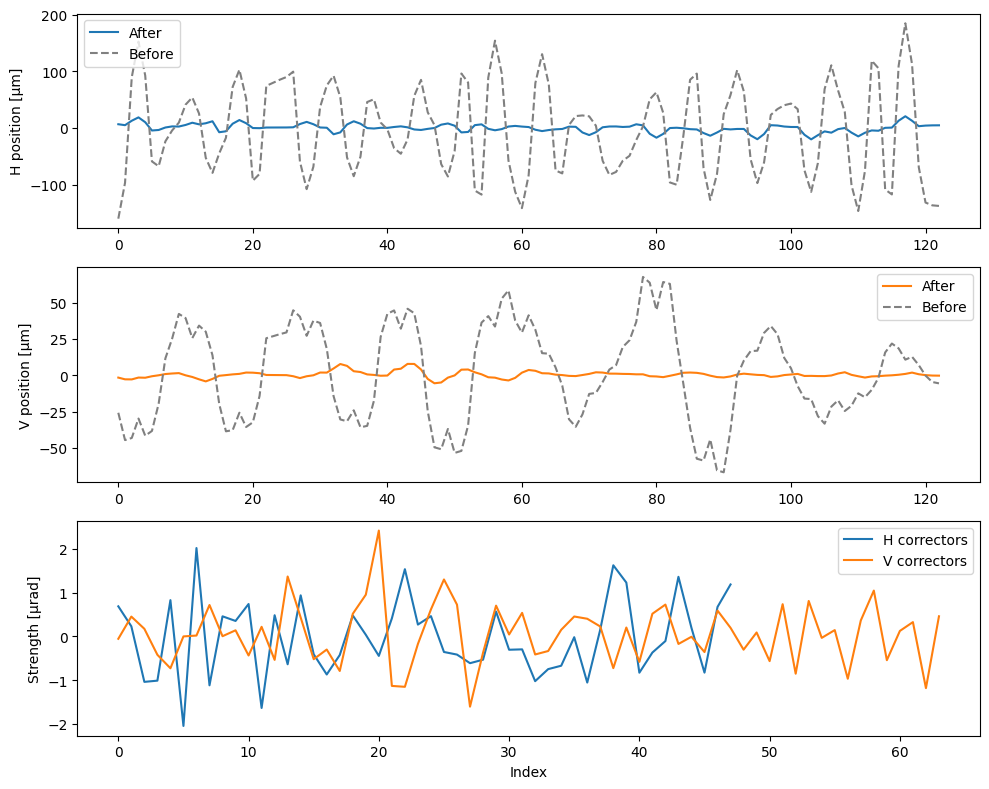

In [13]:
positions_ac = bpms.positions.get()
std_ac = np.std(positions_ac, axis=0)
print(f"R.m.s. orbit after correction  — H: {1e6 * std_ac[0]:.1f} µm, V: {1e6 * std_ac[1]:.1f} µm")

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(positions_ac[:, 0] * 1e6, label="After", color="C0", ls="-")
axes[0].plot(positions_bc[:, 0] * 1e6, label="Before", color="grey", ls="--")

axes[0].set_ylabel("H position [µm]")
axes[0].legend()

axes[1].plot(positions_ac[:, 1] * 1e6, label="After", color="C1", ls="-")
axes[1].plot(positions_bc[:, 1] * 1e6, label="Before", color="grey", ls="--")

axes[1].set_ylabel("V position [µm]")
axes[1].legend()

axes[2].plot(hcorr.strengths.get() * 1e6, label="H correctors")
axes[2].plot(vcorr.strengths.get() * 1e6, label="V correctors")
axes[2].set_ylabel("Strength [µrad]")
axes[2].set_xlabel("Index")
axes[2].legend()

fig.tight_layout()
plt.show()